# Explore here

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"


In [2]:
df = pd.read_csv(url,sep=";")


In [12]:
df.isna().sum()


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [5]:
print("Conteo absoluto:")
print(df['y'].value_counts(dropna=False))

print("\nPorcentajes:")
print(round(df['y'].value_counts(normalize=True)*100, 3))


Conteo absoluto:
y
no     36548
yes     4640
Name: count, dtype: int64

Porcentajes:
y
no     88.735
yes    11.265
Name: proportion, dtype: float64


En el siguiente grafico podemos ver como se distribuyen y nuestro objetivo seria poder hacer que los "SÍ" suban y los "NO" bajen.

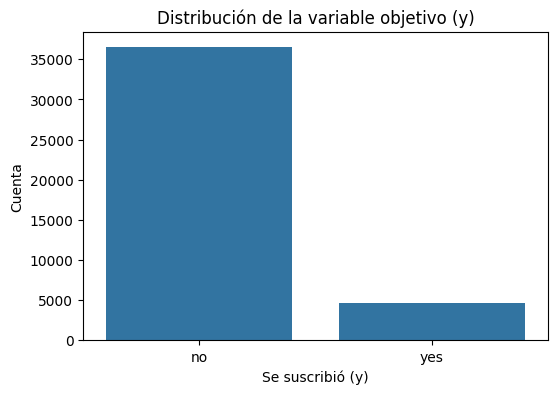

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='y')
plt.title("Distribución de la variable objetivo (y)")
plt.ylabel("Cuenta")
plt.xlabel("Se suscribió (y)")
plt.show()


In [7]:
cols_cat = ['job','marital','education','housing','loan']
for c in cols_cat:
    print("===", c, "===")
    vc = df[c].value_counts(dropna=False)
    print(vc.head(10))
    # porcentaje de aceptacion por categoria
    pct = df.groupby(c)['y'].value_counts(normalize=True).unstack().fillna(0)
    if 'yes' in pct.columns:
        pct_yes = (pct['yes']*100).sort_values(ascending=False)
        print("\n% yes por categoria (top 5):")
        display(pct_yes.head(5))
    print("\n")

=== job ===
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
Name: count, dtype: int64

% yes por categoria (top 5):


job
student       31.428571
retired       25.232558
unemployed    14.201183
admin.        12.972558
management    11.217510
Name: yes, dtype: float64



=== marital ===
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

% yes por categoria (top 5):


marital
unknown     15.000000
single      14.004149
divorced    10.320902
married     10.157253
Name: yes, dtype: float64



=== education ===
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

% yes por categoria (top 5):


education
illiterate             22.222222
unknown                14.500289
university.degree      13.724523
professional.course    11.348465
high.school            10.835523
Name: yes, dtype: float64



=== housing ===
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

% yes por categoria (top 5):


housing
yes        11.619392
no         10.879605
unknown    10.808081
Name: yes, dtype: float64



=== loan ===
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

% yes por categoria (top 5):


loan
no         11.340206
yes        10.931498
unknown    10.808081
Name: yes, dtype: float64

La mayoría de los clientes contactados se sitúa en un rango de edad medio (25–50 años). Además, se aprecia que quienes aceptan la campaña presentan una mediana de edad ligeramente superior en comparación con quienes no lo hacen. Aunque hay valores atípicos a edades altas en ambos grupos, su presencia es reducida y no afecta de manera significativa a la tendencia general.

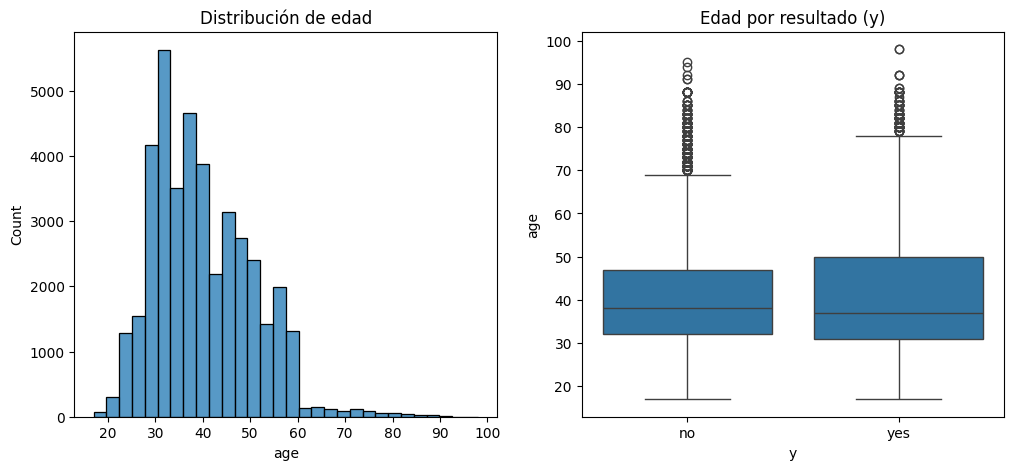

In [8]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['age'].dropna(), bins=30, kde=False)
plt.title("Distribución de edad")

plt.subplot(1,2,2)
sns.boxplot(data=df, x='y', y='age')
plt.title("Edad por resultado (y)")
plt.show()

In [14]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})
